The ``aa.plot_eval_heatmap()`` function renders a static evaluation score grid (e.g. balanced accuracy in percent across part sets and scale sets) as an annotated ``viridis`` heatmap with the package house preset: fixed ``[vmin, vmax]`` color limits, integer cell annotations, horizontal tick labels, and a labeled colorbar. It collapses the hand-built seaborn block that is otherwise copied for every sweep result into one call. It is the simple **static** sibling of ``aap.plot_eval`` (which adaptively summarizes a full ``find_features`` sweep): hand ``plot_eval_heatmap`` a ready-made grid and it applies the look; reach for ``aap.plot_eval`` when you want axis selection and multi-panel layout from a sweep table.

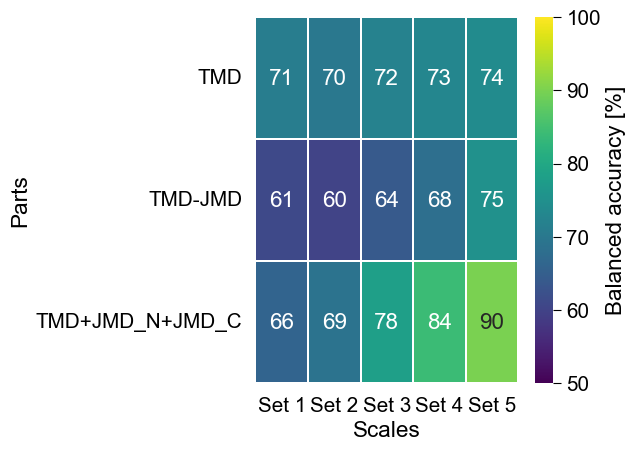

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import aaanalysis as aa

aa.options["verbose"] = False
aa.plot_settings(weight_bold=False, font_scale=0.9)

# A small Parts x Scales balanced-accuracy grid (as in the gamma-secretase use case).
df_eval = pd.DataFrame(
    [[71, 70, 72, 73, 74],
     [61, 60, 64, 68, 75],
     [66, 69, 78, 84, 90]],
    index=["TMD", "TMD-JMD", "TMD+JMD_N+JMD_C"],
    columns=[f"Set {i + 1}" for i in range(5)],
)
ax = aa.plot_eval_heatmap(df_eval=df_eval, xlabel="Scales", ylabel="Parts")
plt.tight_layout()
plt.show()

**Further parameters.** ``plot_eval_heatmap`` also accepts: ``vmin`` / ``vmax`` — lower / upper bounds of the color scale and colorbar (defaults ``50`` / ``100``); ``cbar_label`` — label drawn next to the colorbar (default ``"Balanced accuracy [%]"``, set ``None`` to omit); ``xlabel`` / ``ylabel`` — axis labels (kept as seaborn's default when ``None``); ``ax`` — an existing ``Axes`` to draw on (a new figure is created when ``None``).

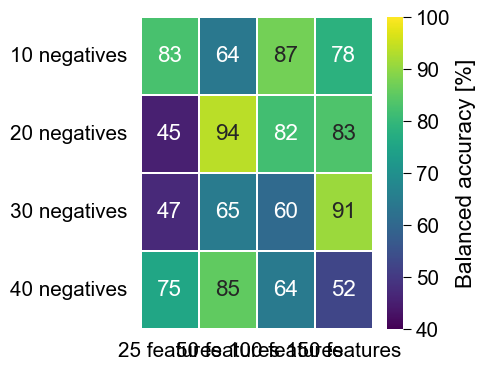

In [2]:
# A different metric range with a custom colorbar label, drawn on a provided Axes.
rng = np.random.default_rng(42)
df_eval2 = pd.DataFrame(
    rng.uniform(40, 95, size=(4, 4)).round(1),
    index=[f"{n} negatives" for n in (10, 20, 30, 40)],
    columns=[f"{n} features" for n in (25, 50, 100, 150)],
)
fig, ax = plt.subplots(figsize=(5, 4))
aa.plot_eval_heatmap(df_eval=df_eval2, vmin=40, vmax=100,
                     cbar_label="Balanced accuracy [%]", ax=ax)
plt.tight_layout()
plt.show()